# Анализ Кадров



In [3]:
!pip install requests beautifulsoup4 pandas openpyxl lxml

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import io
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


### Анализ кадров через сайт rosstat.ru

#### Парсер для rosstat.ru

In [5]:
class RosstatParser:
    BASE_URL = "https://rosstat.gov.ru"

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })

    def get_page(self, url: str) -> BeautifulSoup:
        response = self.session.get(url, timeout=10, verify=False)
        response.raise_for_status()
        return BeautifulSoup(response.text, "lxml")


    def find_excel_links(self, page_url: str) -> list[dict]:
        soup = self.get_page(page_url)
        links = []
        for tag in soup.find_all("a", href=True):
            href = tag["href"]
            if href.endswith((".xlsx", ".xls")):
                full_url = self.BASE_URL + href if href.startswith("/") else href
                links.append({
                    "name": tag.get_text(strip=True),
                    "url": full_url
                })
        return links

    def download_excel(self, url: str) -> pd.DataFrame:
        response = self.session.get(url, timeout=15, verify = False)
        response.raise_for_status()
        return pd.read_excel(io.BytesIO(response.content), header=None)

    def parse_labour_costs(self) -> list[dict]:
        url = f"{self.BASE_URL}/labour_costs"
        print(f"Ищем Excel-файлы на: {url}")
        links = self.find_excel_links(url)
        print(f"Найдено файлов: {len(links)}")
        for link in links:
            print(f"  - {link['name']}: {link['url']}")
        return links

parser = RosstatParser()

In [6]:
links_force = parser.find_excel_links("https://rosstat.gov.ru/labour_force")
print(f"Найдено файлов: {len(links_force)}")
for i, link in enumerate(links_force):
    print(f"[{i}] {link['name']} — {link['url'].split('/')[-1]}")

Найдено файлов: 74
[0] XLSX — Trud_1_15-s.xlsx
[1] XLSX — trud_1_15-72.xlsx
[2] XLSX — Trud_2_15-s.xlsx
[3] XLSX — Trud_2_15-72.xlsx
[4] XLSX — Trud_3_15-s.xlsx
[5] XLSX — Trud_3_15-72.xlsx
[6] XLSX — prs_2025.xlsx
[7] XLSX — s_prs_2025.xlsx
[8] XLSX — trud_vps_2022-2024.xlsx
[9] XLSX — trud_vps_2021-2023.xlsx
[10] XLSX — trud_vps_2020-2022.xlsx
[11] XLSX — trud_vps_2019-2021.xlsx
[12] XLSX — trud_vps_2018-2020.xlsx
[13] XLSX — vps1.xlsx
[14] XLSX — vps2.xlsx
[15] XLSX — vps3.xlsx
[16] XLSX — vps4.xlsx
[17] XLSX — vps5.xlsx
[18] XLSX — vps6.xlsx
[19] XLSX — vps7.xlsx
[20] XLSX — vps8.xlsx
[21] XLSX — vps9.xlsx
[22] XLSX — vps10.xlsx
[23] XLSX — tab1-15-17.xlsx
[24] XLSX — tab2-15-17.xlsx
[25] XLSX — tab3-15-17.xlsx
[26] XLS — tab4-15-17.xls
[27] XLS — tab5-15-17.xls
[28] XLSX — tab6-15-17.xlsx
[29] XLSX — tab7-15-17.xlsx
[30] XLSX — tab8-15-17.xlsx
[31] XLSX — vps1.xlsx
[32] XLSX — vps2.xlsx
[33] XLSX — vps3.xlsx
[34] XLSX — vps4.xlsx
[35] XLSX — vps

In [7]:
links_costs = parser.find_excel_links("https://rosstat.gov.ru/labour_costs")
print(f"Найдено файлов: {len(links_costs)}")
for i, link in enumerate(links_costs):
    print(f"[{i}] {link['name']} — {link['url'].split('/')[-1]}")

Найдено файлов: 11
[0] XLSX — din-zatrat-rs.xlsx
[1] XLSX — raspr1-osn.xlsx
[2] XLS — raspr1_2025.xls
[3] XLS — raspr2_2025.xls
[4] XLS — sr-zpl_2025.xls
[5] XLSX — sr-zpl5_2025.xlsx
[6] XLSX — sr-zpl4_2025.xlsx
[7] XLSX — sr-zpl8-2025.xlsx
[8] XLSX — sr-zpl7_2025.xlsx
[9] XLSX — sr-zpl6_2025.xlsx
[10] XLSX — Mediana_2019-2024.xlsx


In [8]:
df_edu = parser.download_excel(links_costs[7]["url"])
edu_clean = df_edu.iloc[4:10, :].copy()
years_edu = [str(int(float(c))) if str(c) not in ["20251)", "nan"] else "2025" for c in df_edu.iloc[3, 1:].values]
edu_clean.columns = ["категория"] + years_edu
edu_clean["категория"] = [
    "Все работники",
    "Высшее профессиональное",
    "Среднее профессиональное",
    "Среднее общее",
    "Основное общее",
    "Не имеют основного общего"
]
edu_clean = edu_clean.set_index("категория")
edu_clean = edu_clean.apply(pd.to_numeric, errors="coerce")
print("Зарплаты по уровню образования:")
print(edu_clean)

df_med = parser.download_excel(links_costs[10]["url"])
med_clean = df_med.iloc[4, 1:].copy()
years_med = [str(c).replace(" 2", "").strip() for c in df_med.iloc[3, 1:].values]
med_clean.index = years_med
med_clean = pd.to_numeric(med_clean, errors="coerce")
med_clean.name = "медианная_зарплата"
print("\nМедианная зарплата по годам:")
print(med_clean)

Зарплаты по уровню образования:
                               2005     2007     2009     2011     2013  \
категория                                                                 
Все работники               8694.43  13570.0  18084.0  22717.0  28702.0   
Высшее профессиональное    11383.15  17799.0  24366.0  29927.0  38233.0   
Среднее профессиональное    7722.18  11830.0  15276.0  18901.0  23869.0   
Среднее общее               7726.29  11787.0  14780.0  18538.0  22886.0   
Основное общее              6417.65   9992.0  12343.0  15970.0  21622.0   
Не имеют основного общего   5772.46   8997.0  10793.0  14545.0  19850.0   

                              2015     2017     2019     2021     2023  \
категория                                                                
Все работники              32911.0  38609.0  44729.0  57240.0  73664.0   
Высшее профессиональное    43362.0  51316.0  57708.0  75185.0  95065.0   
Среднее профессиональное   26929.0  30777.0  36926.0  45110.0  59495.0 

In [20]:
df_it_old = parser.download_excel(links_force[71]["url"])
it_old = df_it_old.iloc[18, 1:].copy()
years_old = df_it_old.iloc[5, 1:].values
it_old.index = [int(float(y)) for y in years_old]
it_old = pd.to_numeric(it_old, errors="coerce")
it_old.name = "занятые_тыс"

df_it_new = parser.download_excel(links_force[63]["url"])
it_new = df_it_new.iloc[17, 1:].copy()
years_new = df_it_new.iloc[4, 1:].values
it_new.index = [int(float(y)) for y in years_new]
it_new = pd.to_numeric(it_new, errors="coerce")
it_new.name = "занятые_тыс"

it_combined = pd.concat([it_old, it_new])
it_combined = it_combined[~it_combined.index.duplicated()]
it_combined = it_combined.sort_index()
print(it_combined)
      

2010    1332.367
2011    1355.729
2012    1361.998
2013    1360.459
2014    1356.417
2015    1373.036
2016    1413.364
2017    1449.900
2018    1476.900
2019    1488.700
2020    1512.100
2021    1576.000
2022    1636.600
2023    1756.500
2024    1890.600
Name: занятые_тыс, dtype: float64


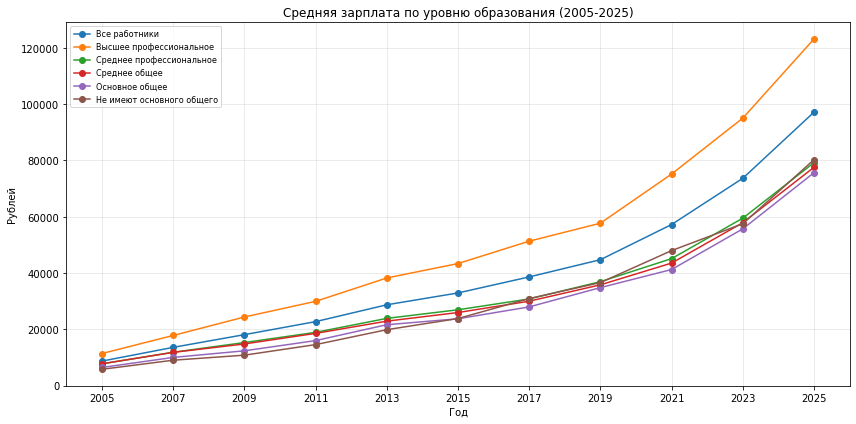

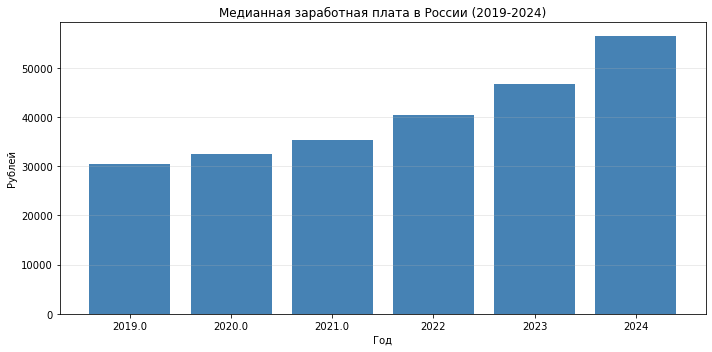

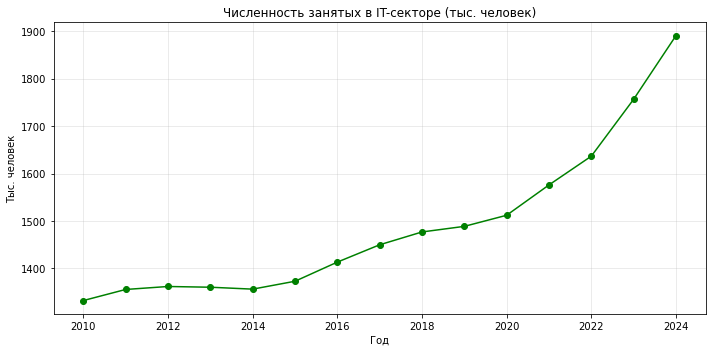

In [22]:
class DataAnalyzer:
    def __init__(self, edu_df, median_series, it_series):
        self.edu = edu_df
        self.median = median_series
        self.it = it_series

    def plot_edu_salaries(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        for category in self.edu.index:
            ax.plot(self.edu.columns, self.edu.loc[category], marker="o", label=category)
        ax.set_title("Средняя зарплата по уровню образования (2005-2025)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Рублей")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_median(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(self.median.index.astype(str), self.median.values, color="steelblue")
        ax.set_title("Медианная заработная плата в России (2019-2024)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Рублей")
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()

    def plot_it_employment(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.it.index, self.it.values, marker="o", color="green")
        ax.set_title("Численность занятых в IT-секторе (тыс. человек)")
        ax.set_xlabel("Год")
        ax.set_ylabel("Тыс. человек")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

analyzer = DataAnalyzer(edu_clean, med_clean, it_combined)
analyzer.plot_edu_salaries()
analyzer.plot_median()
analyzer.plot_it_employment()


### Анализ кадров через сайт hh.ru

Пока разбираюсь с hh.ru (через api нет доступа на данный момент, через динамический парсер в коллабе тоже не открывается, попробую локально сделать, либо буду анализировать данные через реальный датасат в kaggle)